In [12]:
import chardet
with open('restaurant_reviews_sentiment.csv', 'rb') as f:
    result = chardet.detect(f.read())

print(result)

{'encoding': 'MacRoman', 'confidence': 0.7299850882550603, 'language': ''}


In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    'restaurant_reviews_sentiment.csv',
    encoding='mac_roman'
)

# Preview the data
print(df.head())
print(df.shape)          # How many rows/columns
print(df.columns)        # Column names
print(df.isnull().sum()) # Check for missing values

                                              review  sentiment
0                         Not up to the mark service          0
1                                       Food is good          1
2                             Best taste and quality          1
3  (Translated by Google) One of the best bar b q...          1
4  Tasty food and reasonable price. This place is...          1
(19837, 2)
Index(['review', 'sentiment'], dtype='object')
review       0
sentiment    0
dtype: int64


sentiment_label
positive    15420
neutral      2397
negative     2020
Name: count, dtype: int64


/tmp/ipykernel_2542/1709111728.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='Set2')


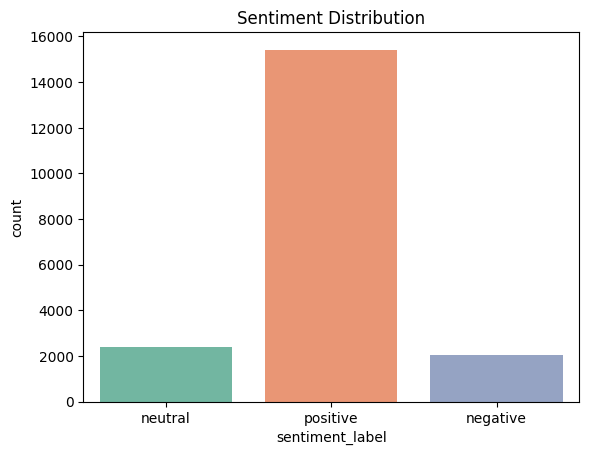

In [39]:
# Cell 3: Map Sentiment & Plot (FIXED: Saved to a new column instead of overwriting 'review')
def map_sentiment(rating):
    if rating == 1:
        return 'positive'
    elif rating == 2:
        return 'negative'
    else:
        return 'neutral'

# FIX: Map into a dedicated label column, keeping the 'review' text intact
df['sentiment_label'] = df['sentiment'].apply(map_sentiment)

# Check distribution
print(df['sentiment_label'].value_counts())

# Visualize
sns.countplot(x='sentiment_label', data=df, palette='Set2')
plt.title('Sentiment Distribution')
plt.show()

In [40]:
# Cell 4: Clean Text
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase everything
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenize (split into words)
    words = text.split()

    # 5. Remove stopwords
    words = [w for w in words if w not in stop_words]

    # 6. Lemmatize
    words = [lemmatizer.lemmatize(w) for w in words]

    # 7. Rejoin into a clean string
    return ' '.join(words)

# Apply cleaning to your raw review text column
df['clean_text'] = df['review'].apply(clean_text)

# Preview
print(df[['review', 'clean_text']].head(3))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                       review          clean_text
0  Not up to the mark service        mark service
1                Food is good           food good
2      Best taste and quality  best taste quality


In [41]:
# Cell 5: Train-Test Split & TF-IDF Vectorization (FIXED: Splitting 'clean_text')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# FIX: X must represent your text data features, and y represents your numerical target classes
X = df['clean_text']
y = df['sentiment']

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: converts text to numerical feature vectors
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)  # Learn vocabulary from training data
X_test_tfidf = tfidf.transform(X_test)         # Apply same vocabulary to test data

print(f"Training samples: {X_train_tfidf.shape[0]}")
print(f"Features (words): {X_train_tfidf.shape[1]}") # This will no longer be 3!

Training samples: 15869
Features (words): 10000



Training samples (after SMOTE):  37008

Class distribution after SMOTE:
sentiment
1    12336
2    12336
0    12336
Name: count, dtype: int64


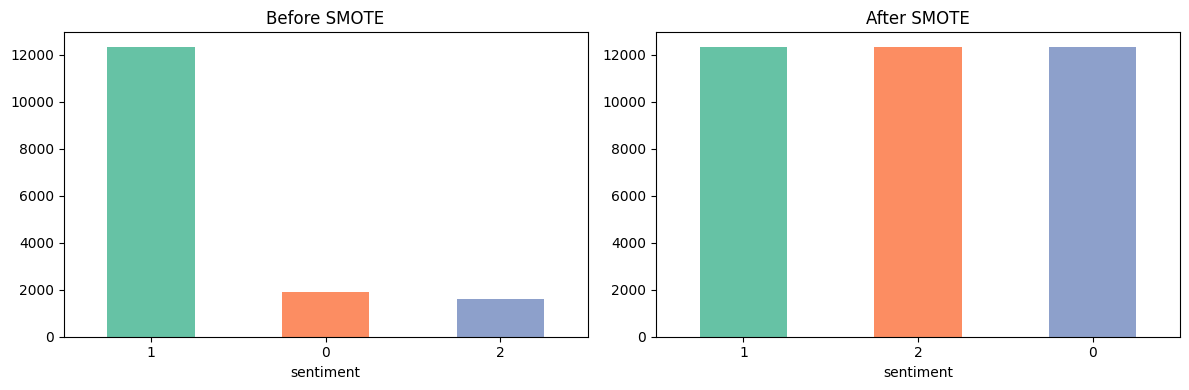

In [42]:
# ─────────────────────────────────────────────
# SMOTE — applied ONLY on the training set
# ─────────────────────────────────────────────
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',   # upsample all minority classes to match the majority
    k_neighbors=5,              # number of nearest neighbours used for synthesis
    random_state=42
)

# SMOTE needs a dense or sparse matrix — TF-IDF sparse matrix works directly
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print(f"\nTraining samples (after SMOTE):  {X_train_smote.shape[0]}")
print(f"\nClass distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

# Quick visualisation of before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], color=sns.color_palette('Set2'),
    title='Before SMOTE', rot=0
)
pd.Series(y_train_smote).value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('Set2'),
    title='After SMOTE', rot=0
)
plt.tight_layout()
plt.show()

In [43]:
# ─────────────────────────────────────────────
# MODEL TRAINING — use X_train_smote & y_train_smote
# ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ⚠️  MultinomialNB requires non-negative values.
# SMOTE interpolation can occasionally produce tiny negatives in TF-IDF space.
# The MinMaxScaler call below prevents that.
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import issparse

def to_non_negative(X):
    """Clip any near-zero negatives introduced by SMOTE interpolation."""
    if issparse(X):
        X = X.toarray()
    return np.clip(X, 0, None)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, C=1.0),        False),
    'Naive Bayes':         (MultinomialNB(alpha=0.1),                         True),   # needs non-negative
    'Linear SVM':          (LinearSVC(max_iter=2000),                         False),
}

results = {}

for name, (model, needs_nonneg) in models.items():
    Xtr = to_non_negative(X_train_smote) if needs_nonneg else X_train_smote
    Xte = to_non_negative(X_test_tfidf)  if needs_nonneg else X_test_tfidf

    model.fit(Xtr, y_train_smote)
    y_pred = model.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{'='*40}")
    print(f"Model: {name} | Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name} with accuracy {results[best_model_name]:.4f}")


Model: Logistic Regression | Accuracy: 0.7528
              precision    recall  f1-score   support

           0       0.31      0.43      0.36       480
           1       0.91      0.82      0.86      3084
           2       0.49      0.62      0.55       404

    accuracy                           0.75      3968
   macro avg       0.57      0.63      0.59      3968
weighted avg       0.79      0.75      0.77      3968


Model: Naive Bayes | Accuracy: 0.7124
              precision    recall  f1-score   support

           0       0.25      0.48      0.33       480
           1       0.92      0.76      0.83      3084
           2       0.50      0.65      0.56       404

    accuracy                           0.71      3968
   macro avg       0.56      0.63      0.58      3968
weighted avg       0.80      0.71      0.74      3968


Model: Linear SVM | Accuracy: 0.7450
              precision    recall  f1-score   support

           0       0.28      0.39      0.32       480
     

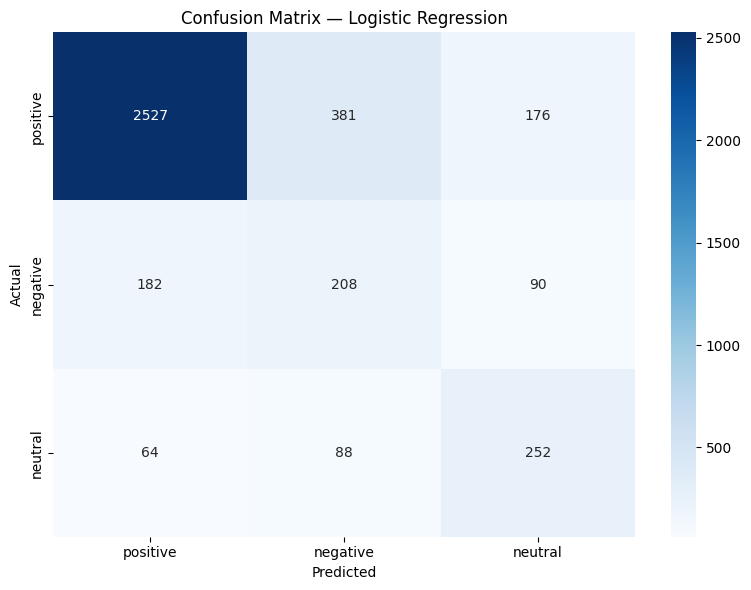

In [44]:
# ─────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────
best_model, needs_nonneg = models[best_model_name]
Xte = to_non_negative(X_test_tfidf) if needs_nonneg else X_test_tfidf
y_pred_best = best_model.predict(Xte)

cm = confusion_matrix(y_test, y_pred_best, labels=[1, 0, 2])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'negative', 'neutral'],  # 1=pos, 2=neg, 3=neutral
            yticklabels=['positive', 'negative', 'neutral'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [45]:
import pickle

# Save the trained model and vectorizer
with open('sentiment_model.pkl', 'wb') as f:
   pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model and vectorizer saved!")

# --- HOW TO LOAD AND USE IN YOUR APP ---
def predict_sentiment(review_text):
    # Load model and vectorizer
    with open('sentiment_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)

    # Clean and transform input
    cleaned = clean_text(review_text)
    vectorized = vectorizer.transform([cleaned])

    # Predict
    prediction = model.predict(vectorized)[0]
    return prediction

# Test it
sample = "not as good as we thought"
print(f"Review: {sample}")
print(f"Sentiment: {predict_sentiment(sample)}")

✅ Model and vectorizer saved!
Review: not as good as we thought
Sentiment: 2
